In [2]:
import torch
import numpy as np
import cv2
import copy
import os
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import csv
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from scipy.stats import chi2_contingency
plt.rcParams['font.family'] = ['serif']
plt.rcParams['font.serif'] = ['Times New Roman']

In [10]:
project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
sys.path.append(project_root)

NameError: name '__file__' is not defined

In [4]:
model_name="MatSegNet"

In [5]:
base_directory=Path('C:/Users/xiaoh/Desktop/3rd-Paper/Segmentation_Pipeline')

images_saved_dir=os.path.join(base_directory,'outputs','MatSegNet_qualitative_results',"Carbide_orientations") 
bainite = os.path.join(base_directory,'outputs','MatSegNet_qualitative_results','Predictions','bainite') 
martensite =os.path.join(base_directory,'outputs','MatSegNet_qualitative_results','Predictions','martensite')  

bainite_list = [os.path.join(bainite,i) for i in os.listdir(bainite)]
martensite_list = [os.path.join(martensite,i) for i in os.listdir(martensite)]

print(f'there are {len(bainite_list)} bainite images, and {len(martensite_list)} martensite images')

there are 1304 bainite images, and 261 martensite images


In [6]:
def highlight_carbides(image_path, output_dir, number=0, name='Name', ratio=2):
    """
    Analyzes an image to identify carbides, highlights them with bounding boxes,
    and generates a histogram of their angular distribution.

    Args:
        image_path (str): The full path to the input image file.
        output_dir (str): The directory where output images will be saved.
        number (int, optional): An identifier number for the output files. Defaults to 0.
        name (str, optional): A name identifier for the output files. Defaults to 'Name'.
        ratio (float, optional): The aspect ratio for the histogram plot. Defaults to 2.

    Returns:
        float: The percentage of carbides found in the most frequent orientation bin.
               Returns 0.0 if no carbides are found. Returns None on file read error.
    """
  
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    comparison_highlighted_dir=os.path.join(output_dir,"Merged Highlighted Carbides")
    orientation_histogram_dir=os.path.join(output_dir,"Carbide Orientation")
    highlighted_dir=os.path.join(output_dir,"Carbide Highlighted")
    
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(comparison_highlighted_dir, exist_ok=True)
    os.makedirs(orientation_histogram_dir, exist_ok=True)
    os.makedirs(highlighted_dir, exist_ok=True)
    
    # 2. Read the source image and handle potential errors
    img_raw = cv2.imread(image_path)
    if img_raw is None:
        print(f"Error: File not found or could not be opened at path: {image_path}")
        return None

    # 3. Create a copy for drawing and convert to grayscale
    img_with_boxes = copy.deepcopy(img_raw)
    gray = cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2GRAY)

    # 4. Binarize the image and find contours
    _, bw = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(bw, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    
    angle_list = []
    for c in contours:
        # Filter out very small or very large contours
        area = cv2.contourArea(c)
        if not (30 < area < 100000):
            continue
        
        # Get the minimum area rotated rectangle
        rect = cv2.minAreaRect(c)
        box = cv2.boxPoints(rect)
        box = box.astype(int)

        # Normalize the angle to be the orientation of the longer side
        width, height = rect[1]
        angle = rect[2]

        if width < height:
            angle = 90 - angle
        else:
            angle = -angle
            
        angle_list.append(angle)
        cv2.drawContours(img_with_boxes, [box], 0, (80, 127, 255), 2)

    # 5. Save a side-by-side comparison image
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
    axs[0].imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB))
    axs[0].set_title('Original Image', fontsize=20)
    axs[0].axis('off')
    
    axs[1].imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
    axs[1].set_title('Carbide Orientation Highlighted', fontsize=20)
    axs[1].axis('off')

    comparison_filename = f"{name}_{number}_comparison.jpg"
    plt.savefig(os.path.join(comparison_highlighted_dir, comparison_filename), dpi=100, bbox_inches='tight')
    plt.close(fig)

    # 6. Save the final image with highlighted carbides
    highlighted_filename = f"{name}_{number}_highlighted.jpg"
    cv2.imwrite(os.path.join(highlighted_dir  , highlighted_filename), img_with_boxes)

    # 7. Handle the case where no valid carbides were found
    if not angle_list:
        print(f"Warning: No valid carbides found in image {name}_{number}.")
        return 0.0

    # 8. Create and save the angle distribution histogram if carbides were found
    fig, ax = plt.subplots(figsize=(16, 9))
    counts, bins, patches = ax.hist(angle_list, color='blue', alpha=0.7, bins=18, range=(-90, 90), edgecolor='black', linewidth=2)
    
    # Add count labels above each bar
    for rect_patch in patches:
        height = rect_patch.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}', 
                        xy=(rect_patch.get_x() + rect_patch.get_width() / 2, height),
                        xytext=(0, 5), textcoords='offset points', ha='center', va='bottom')
    
    ax.set_aspect(ratio)
    ax.set_title('Carbide Angle Distribution', fontsize=20)
    ax.set_xlim(-100, 100)
    ax.set_xlabel('Angle (°)', fontsize=20)
    ax.set_ylabel('Number of Carbides', fontsize=20)
    ax.set_xticks(np.arange(-90, 91, 10))
    for axis in ['top', 'bottom', 'left', 'right']:
        ax.spines[axis].set_linewidth(2)
    ax.tick_params(axis='both', which='major', labelsize=10, direction='in', length=4)
    
    histogram_filename = f"{name}_{number}_histogram.jpg"
    plt.savefig(os.path.join(orientation_histogram_dir, histogram_filename), dpi=100)
    plt.close(fig)

    # 9. Calculate the percentage of the most frequent angle
    max_count = np.max(counts)
    total_count = np.sum(counts)
    angle_percentage = max_count / total_count if total_count > 0 else 0.0

    return angle_percentage

In [7]:
pwd

'C:\\Users\\xiaoh\\Desktop\\3rd-Paper\\Segmentation_Pipeline\\inference'

In [8]:
def get_percentage_list(dataset ,images_saved_dirname,name='Name'):
    output_list = []
    for i, image_path in enumerate(dataset):
        print('Processing image {}: {}'.format(i, image_path))
        percentage = highlight_carbides(image_path, images_saved_dir,number=i, name=name)
        if percentage is not None:
            output_list.append(percentage)
        else:
            print(f"Skipping image {i} ({image_path}) due to an error.")

    return output_list

In [9]:
bainite_k_list=get_percentage_list(bainite_list,images_saved_dir,name="Lower_Bainite")
martensite_k_list=get_percentage_list(martensite_list,images_saved_dir,name="Tempered_Martensite")
 

Processing image 0: C:\Users\xiaoh\Desktop\3rd-Paper\Segmentation_Pipeline\outputs\MatSegNet_qualitative_results\Predictions\bainite\42CrMo4BAINITE_0.3-2500X_005_0_0.png
Processing image 1: C:\Users\xiaoh\Desktop\3rd-Paper\Segmentation_Pipeline\outputs\MatSegNet_qualitative_results\Predictions\bainite\42CrMo4BAINITE_0.3-2500X_005_0_1.png
Processing image 2: C:\Users\xiaoh\Desktop\3rd-Paper\Segmentation_Pipeline\outputs\MatSegNet_qualitative_results\Predictions\bainite\42CrMo4BAINITE_0.3-2500X_005_0_10.png
Processing image 3: C:\Users\xiaoh\Desktop\3rd-Paper\Segmentation_Pipeline\outputs\MatSegNet_qualitative_results\Predictions\bainite\42CrMo4BAINITE_0.3-2500X_005_0_11.png
Processing image 4: C:\Users\xiaoh\Desktop\3rd-Paper\Segmentation_Pipeline\outputs\MatSegNet_qualitative_results\Predictions\bainite\42CrMo4BAINITE_0.3-2500X_005_0_12.png
Processing image 5: C:\Users\xiaoh\Desktop\3rd-Paper\Segmentation_Pipeline\outputs\MatSegNet_qualitative_results\Predictions\bainite\42CrMo4BAINITE

In [10]:
def get_area_percentage(dataset, color_channel=1, threshold=0.9):

    ratio_list = []
    # 使用 enumerate 获取索引和路径，更 Pythonic
    for i, image_path in enumerate(dataset):
        try:
            img = imageio.imread(image_path)

            # 检查图像是否为灰度图或通道数不足
            if len(img.shape) < 3 or img.shape[2] <= color_channel:
                print(f"Warning: Skipping image {i} ({image_path}) because it's grayscale or has too few channels.")
                continue # 跳过这张图片

            # 核心计算逻辑不变
            pixel_count = np.sum(img[:, :, color_channel] / 255 > threshold)
            total_pixels = img.shape[0] * img.shape[1]
            
            ratio = pixel_count / total_pixels if total_pixels > 0 else 0.0
            ratio_list.append(ratio)

        except FileNotFoundError:
            print(f"Error: File not found at {image_path}. Skipping.")
        except Exception as e:
            print(f"An error occurred while processing {image_path}: {e}. Skipping.")
            
    return ratio_list

In [11]:
bain_area_percentage_list=get_area_percentage(bainite_list)
mar_area_percentage_list=get_area_percentage(martensite_list)

hypothesis testing, confidence interval estimation, or ANOVA.

In [12]:
def plot_comparison_scatter(ax, data1, data2, label1, label2, title, ylabel, subplot_label):
    """
    一个辅助函数，用于在给定的坐标轴(ax)上绘制两个数据集的对比散点图。

    参数:
    ax (matplotlib.axes.Axes): 要在其上绘图的子图坐标轴对象。
    data1, data2 (list or np.array): 两个要比较的数据集。
    label1, label2 (str): 两个数据集的标签名称。
    title (str): 子图的标题。
    ylabel (str): Y轴的标签。
    subplot_label (str): 子图的标签，例如 '(a)'。
    """
    # 1. 计算统计数据
    avg1, std1 = np.average(data1), np.std(data1)
    avg2, std2 = np.average(data2), np.std(data2)

    # 2. 绘制数据点和平均值线
    # 为数据点和平均值线添加标签，以便自动生成图例
    ax.scatter(np.arange(len(data1)), data1, facecolors='none', color='red', s=50, label=label1)
    ax.plot([-5, 360], [avg1, avg1], color='red')
    
    ax.scatter(np.arange(len(data2)), data2, facecolors='none', color='blue', marker='^', s=50, label=label2)
    ax.plot([-5, 360], [avg2, avg2], color='blue', linestyle='dashed')

    # 3. 添加统计信息文本框
    stats_text = (
        f"{label1}:\n"
        f"  Average: {avg1:.2f}   STD: {std1:.4f}\n\n"
        f"{label2}:\n"
        f"  Average: {avg2:.2f}   STD: {std2:.4f}"
    )
    # 动态确定文本位置
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.2)
    ymin_new, ymax_new = ax.get_ylim()
    text_y_pos = ymin_new + (ymax_new - ymin_new) * 0.95 # 放在顶部
    ax.text(10, text_y_pos, stats_text, fontsize=14, verticalalignment='top')

    # 4. 设置标题和标签
    ax.set_title(title, fontsize=18, pad=10)
    ax.set_xlabel('Image Number', fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
   # ax.set_xlim(-5, 360)
    
    # 5. 设置子图标签 (a), (b) ...
    # 使用 ax.transAxes 使其位置相对于坐标轴本身，更稳定
    ax.text(0.02, 0.98, subplot_label, transform=ax.transAxes, fontsize=16,
            fontweight='bold', verticalalignment='top')

    # 6. 美化坐标轴和刻度
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.tick_params(axis='both', which='major', labelsize=15, direction='in', width=2, length=6)




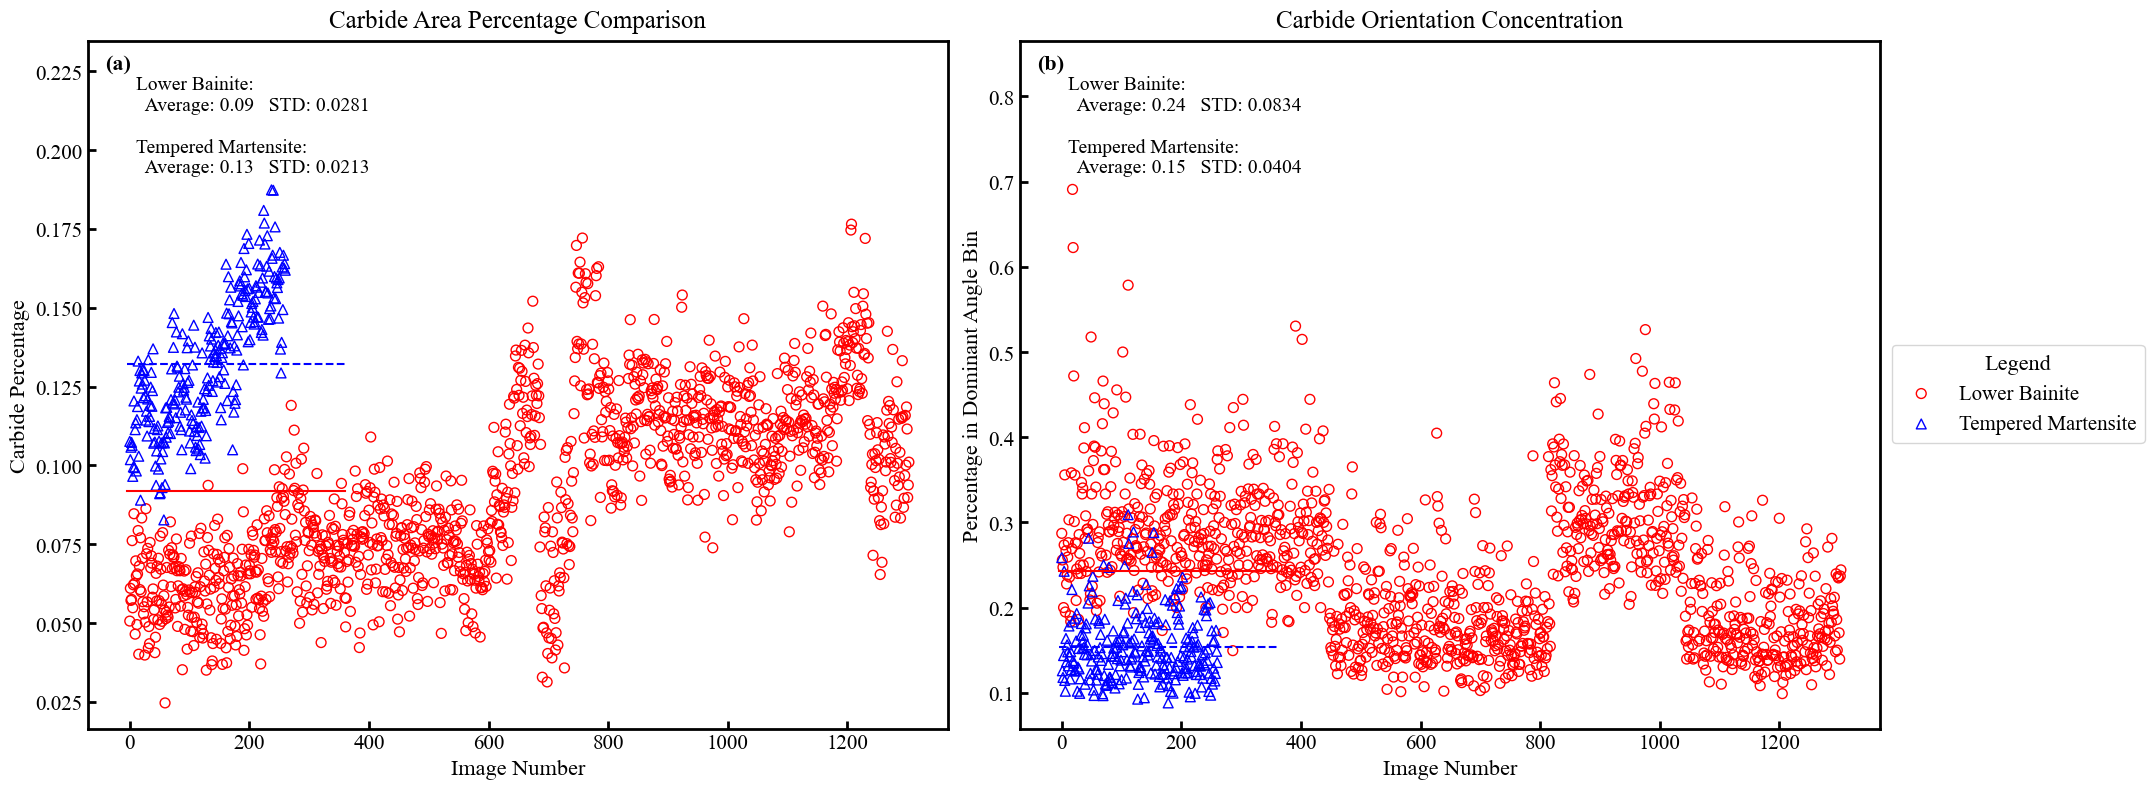

In [13]:


# 1. 创建图床和子图 (这是创建子图的最佳方式)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# 2. 调用辅助函数绘制第一个子图
plot_comparison_scatter(
    ax=ax1,
    data1=bain_area_percentage_list,
    data2=mar_area_percentage_list,
    label1='Lower Bainite',
    label2='Tempered Martensite',
    title='Carbide Area Percentage Comparison',
    ylabel='Carbide Percentage',
    subplot_label='(a)'
)

# 3. 调用辅助函数绘制第二个子图
plot_comparison_scatter(
    ax=ax2,
    data1=bainite_k_list,
    data2=martensite_k_list,
    label1='Lower Bainite',
    label2='Tempered Martensite',
    title='Carbide Orientation Concentration',
    ylabel='Percentage in Dominant Angle Bin',
    subplot_label='(b)'
)

# 4. 创建一个统一的图例
# 从 ax2 获取所有元素的句柄和标签
handles, labels = ax2.get_legend_handles_labels()
# 在图的右侧居中位置创建一个统一的图例
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.08, 0.5), fontsize=15, title="Legend", title_fontsize=16)

# 5. 调整布局并保存
# rect参数为图例留出空间
fig.tight_layout(rect=[0, 0, 0.95, 1])
plt.savefig(f"Orientation_Percentage_Optimized_{model_name}.jpg", dpi=600)
plt.show()

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
import matplotlib.gridspec as gridspec

def plot_comparison_figure(lb_data_a, tm_data_a, lb_data_b, tm_data_b, 
                           ylabel_a='Carbide Percentage', ylabel_b='k', 
                           save_path=None):
    
    # --- 0. 准备工作：字体和辅助函数 ---
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']
    plt.rcParams['axes.labelweight'] = 'normal'

    def calculate_ci(data, confidence=0.95):
        """计算给定数据的均值的置信区间"""
        n = len(data)
        mean = np.mean(data)
        sem = scipy.stats.sem(data)
        if sem > 0:
            ci_range = scipy.stats.t.interval(confidence, n - 1, loc=mean, scale=sem)
            return mean, ci_range
        else:
            return mean, (mean, mean)

    # --- 1. 计算统计数据和置信区间 ---
    lb_mean_a, lb_ci_a = calculate_ci(lb_data_a)
    tm_mean_a, tm_ci_a = calculate_ci(tm_data_a)
    lb_mean_b, lb_ci_b = calculate_ci(lb_data_b)
    tm_mean_b, tm_ci_b = calculate_ci(tm_data_b)

    # --- 2. 动态计算所有子图的坐标轴范围 ---
    combined_data_a = np.concatenate((lb_data_a, tm_data_a))
    min_a, max_a = combined_data_a.min(), combined_data_a.max()
    range_a = max_a - min_a
    scatter_ylim_a = (min_a - 0.1 * range_a, max_a + 0.3 * range_a)
    hist_xlim_a = (min_a - 0.05 * range_a, max_a + 0.05 * range_a)
    counts_a_lb, _ = np.histogram(lb_data_a, bins=20)
    counts_a_tm, _ = np.histogram(tm_data_a, bins=20)
    max_count_a = max(counts_a_lb.max(), counts_a_tm.max())
    hist_ylim_a = (0, max_count_a * 1.1)

    combined_data_b = np.concatenate((lb_data_b, tm_data_b))
    min_b, max_b = combined_data_b.min(), combined_data_b.max()
    range_b = max_b - min_b
    scatter_ylim_b = (min_b - 0.1 * range_b, max_b + 0.3 * range_b)
    hist_xlim_b = (min_b - 0.05 * range_b, max_b + 0.05 * range_b)
    counts_b_lb, _ = np.histogram(lb_data_b, bins=25)
    counts_b_tm, _ = np.histogram(tm_data_b, bins=25)
    max_count_b = max(counts_b_lb.max(), counts_b_tm.max())
    hist_ylim_b = (0, max_count_b * 1.1)

    # --- 3. 创建图形和子图布局 ---
    fig = plt.figure(figsize=(12, 14))
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3, height_ratios=[2, 1, 1])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])
    ax5 = fig.add_subplot(gs[2, 0])
    ax6 = fig.add_subplot(gs[2, 1])

    # --- 4. 绘制所有子图 ---
    # (这部分代码没有变化)
    # 子图 (a) 和 (b) ... (省略未改动部分以保持简洁)
    # 子图 (a)
    ax1.scatter(range(len(lb_data_a)), lb_data_a, facecolors='none', edgecolors='royalblue', marker='o', label='LB')
    ax1.scatter(range(len(tm_data_a)), tm_data_a, facecolors='none', edgecolors='orchid', marker='^', label='TM')
    ax1.axhline(y=lb_mean_a, color='royalblue', linestyle='-')
    ax1.axhline(y=tm_mean_a, color='orchid', linestyle='--')
    ax1.fill_between(range(len(lb_data_a)), lb_ci_a[0], lb_ci_a[1], color='royalblue', alpha=0.2)
    ax1.fill_between(range(len(lb_data_a)), tm_ci_a[0], tm_ci_a[1], color='orchid', alpha=0.2)
    ax1.set_title('(a)', loc='left', fontsize=16)
    ax1.set_xlabel('Image Index', fontsize=14)
    ax1.set_ylabel(ylabel_a, fontsize=14)
    ax1.text(0.05, 0.95, f'LB: Avg={lb_mean_a:.2f}, STD={np.std(lb_data_a):.2f}\n    95% CI: [{lb_ci_a[0]:.2f}, {lb_ci_a[1]:.2f}]\nTM: Avg={tm_mean_a:.2f}, STD={np.std(tm_data_a):.2f}\n    95% CI: [{tm_ci_a[0]:.2f}, {tm_ci_a[1]:.2f}]',
             transform=ax1.transAxes, fontsize=12, verticalalignment='top')
    ax1.tick_params(axis='both', which='major', labelsize=12)
    ax1.legend(loc='upper right', fontsize=12)

    # 子图 (b)
    ax2.scatter(range(len(lb_data_b)), lb_data_b, facecolors='none', edgecolors='royalblue', marker='o', label='LB')
    ax2.scatter(range(len(tm_data_b)), tm_data_b, facecolors='none', edgecolors='orchid', marker='^', label='TM')
    ax2.axhline(y=lb_mean_b, color='royalblue', linestyle='-')
    ax2.axhline(y=tm_mean_b, color='orchid', linestyle='--')
    ax2.fill_between(range(len(lb_data_b)), lb_ci_b[0], lb_ci_b[1], color='royalblue', alpha=0.2)
    ax2.fill_between(range(len(lb_data_b)), tm_ci_b[0], tm_ci_b[1], color='orchid', alpha=0.2)
    ax2.set_title('(b)', loc='left', fontsize=16)
    ax2.set_xlabel('Image Index', fontsize=14)
    ax2.set_ylabel(ylabel_b, fontsize=14)
    ax2.text(0.05, 0.95, f'LB: Avg={lb_mean_b:.2f}, STD={np.std(lb_data_b):.2f}\n    95% CI: [{lb_ci_b[0]:.2f}, {lb_ci_b[1]:.2f}]\nTM: Avg={tm_mean_b:.2f}, STD={np.std(tm_data_b):.2f}\n    95% CI: [{tm_ci_b[0]:.2f}, {tm_ci_b[1]:.2f}]',
             transform=ax2.transAxes, fontsize=12, verticalalignment='top')
    ax2.tick_params(axis='both', which='major', labelsize=12)
    ax2.legend(loc='upper right', fontsize=12)

    # --- 新增改动在这里 ---
    # 为 (c) 和 (e) 创建共用的bins
    # 我们使用之前为x轴范围计算好的 hist_xlim_a 来确保bins覆盖所有数据
    common_bins_a = np.linspace(hist_xlim_a[0], hist_xlim_a[1], 20 + 1) # 20个柱子需要21个边界

    # 为 (d) 和 (f) 创建共用的bins
    common_bins_b = np.linspace(hist_xlim_b[0], hist_xlim_b[1], 25 + 1) # 25个柱子需要26个边界
    
    # 直方图
    # --- 在这里应用 common_bins_a ---
    ax3.hist(lb_data_a, bins=common_bins_a, color='royalblue', alpha=0.7, label='LB', edgecolor='black', linewidth=1.2)
    ax3.set_title('(c)', loc='left', fontsize=16)
    ax3.set_ylabel('Image number', fontsize=14)
    ax3.legend(fontsize=12)
    
    # --- 在这里应用 common_bins_a ---
    ax5.hist(tm_data_a, bins=common_bins_a, color='orchid', alpha=0.7, label='TM', edgecolor='black', linewidth=1.2)
    ax5.set_title('(e)', loc='left', fontsize=16)
    ax5.set_xlabel(ylabel_a.lower(), fontsize=14)
    ax5.set_ylabel('Image number', fontsize=14)
    ax5.legend(fontsize=12)
    
    # --- 在这里应用 common_bins_b ---
    ax4.hist(lb_data_b, bins=common_bins_b, color='royalblue', alpha=0.7, label='LB', edgecolor='black', linewidth=1.2)
    ax4.set_title('(d)', loc='left', fontsize=16)
    ax4.set_ylabel('Image number', fontsize=14)
    ax4.legend(fontsize=12)

    # --- 在这里应用 common_bins_b ---
    ax6.hist(tm_data_b, bins=common_bins_b, color='orchid', alpha=0.7, label='TM', edgecolor='black', linewidth=1.2)
    ax6.set_title('(f)', loc='left', fontsize=16)
    ax6.set_xlabel(ylabel_b, fontsize=14)
    ax6.set_ylabel('Image number', fontsize=14)
    ax6.legend(fontsize=12)

    # --- 5. 应用统一且动态的坐标轴范围 ---
    # (这部分代码没有变化)
    ax1.set_xlim(0, len(lb_data_a) - 1)
    ax2.set_xlim(0, len(lb_data_b) - 1)
    ax1.set_ylim(scatter_ylim_a)
    ax2.set_ylim(scatter_ylim_b)
    ax3.set_xlim(hist_xlim_a)
    ax5.set_xlim(hist_xlim_a)
    ax3.set_ylim(hist_ylim_a)
    ax5.set_ylim(hist_ylim_a)
    ax4.set_xlim(hist_xlim_b)
    ax6.set_xlim(hist_xlim_b)
    ax4.set_ylim(hist_ylim_b)
    ax6.set_ylim(hist_ylim_b)
    
    # --- 6. 显示或保存图形 ---
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"图形已保存至: {save_path}")
        plt.close(fig)
    else:
        plt.show()

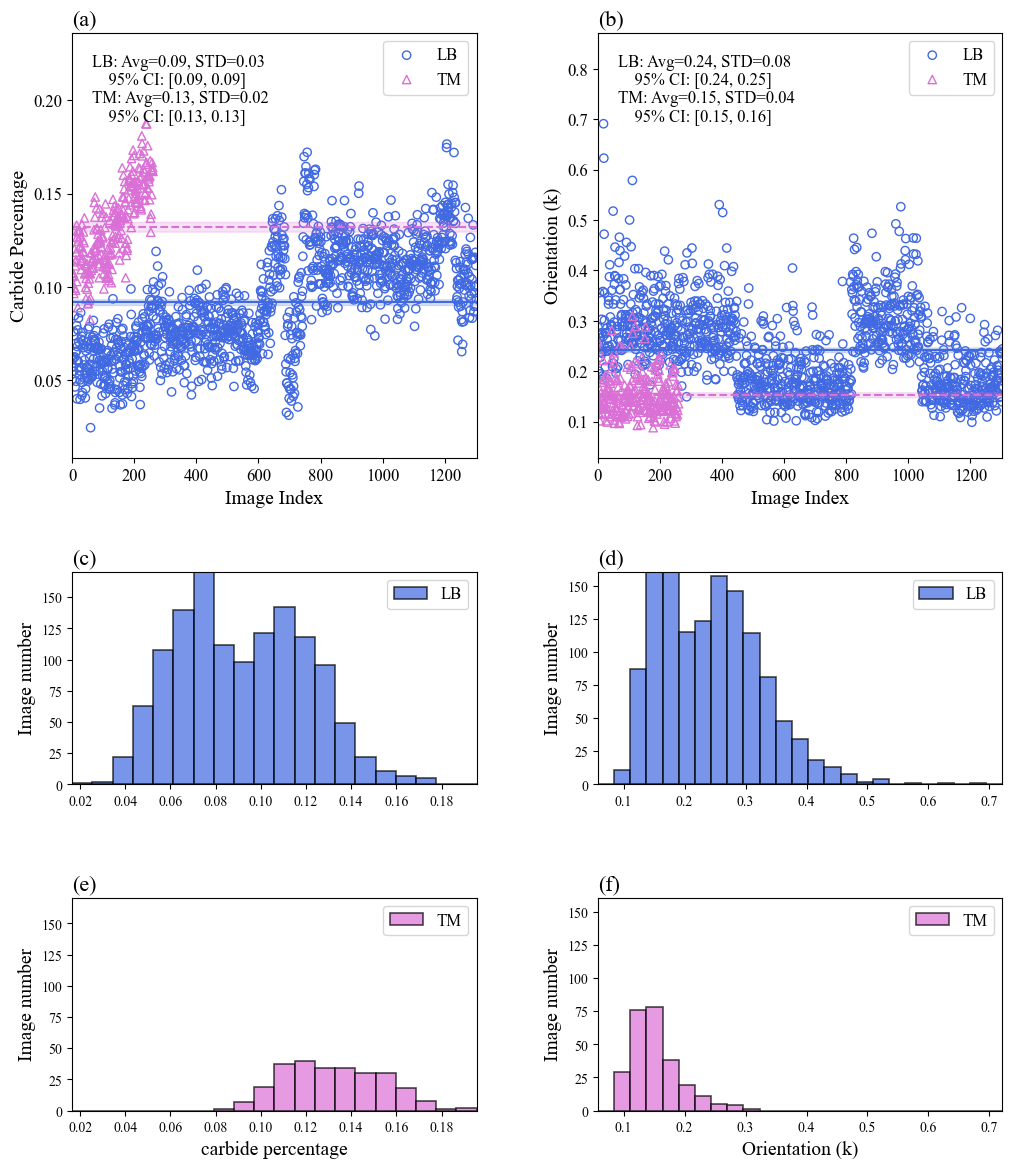

In [22]:
plot_comparison_figure(
        lb_data_a=bain_area_percentage_list,
        tm_data_a=mar_area_percentage_list,
        lb_data_b=bainite_k_list,
        tm_data_b=martensite_k_list,
        ylabel_a='Carbide Percentage',
        ylabel_b='Orientation (k)'
    )

In [11]:
data_to_write = {
    'Carbide percentage_bain: ': bain_area_percentage_list,
    'Carbide percentage Mar: ': mar_area_percentage_list,
    'Carbide orientation Bain: ': bainite_k_list,
    'Carbide orientation Mar: ': martensite_k_list
} 

with open(f'Percentage_Orientation_v2_{model_name}.csv', "w", newline='') as csv_file:
    writer = csv.writer(csv_file)
    
    # This part was already correct
    for header, data_list in data_to_write.items():
        writer.writerow([header])
        writer.writerow(data_list)
        
    # Add a blank row for spacing
    writer.writerow([]) 
    
    # --- T-test for Carbide Percentages ---
    t_stat, p_val = stats.ttest_ind(bain_area_percentage_list, mar_area_percentage_list)

    writer.writerow([f"t-statistic for carbide percentages: {t_stat}"]) 
    writer.writerow([f"p-value for carbide percentages: {p_val}"])     

    if p_val < 0.05:
        writer.writerow(["Conclusion: Reject the null hypothesis. The difference between the group means is statistically significant."]) 
    else:
        writer.writerow(["Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference between the groups."]) 
    
    # Add a blank row for spacing
    writer.writerow([]) 
        
    # --- T-test for Carbide Orientations ---
    t_stat, p_val = stats.ttest_ind(bainite_k_list, martensite_k_list)

    # Wrap each string in a list []
    writer.writerow([f"t-statistic for carbide orientations: {t_stat}"]) 
    writer.writerow([f"p-value for carbide orientations: {p_val}"])    

    if p_val < 0.05:
        writer.writerow(["Conclusion: Reject the null hypothesis. The difference between the group means is statistically significant."]) 
    else:
        writer.writerow(["Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference between the groups."]) 

print(f"File 'Percentage_Orientation_v2_{model_name}.csv' has been written successfully.")


NameError: name 'bain_area_percentage_list' is not defined